In [1]:
from system_functions import *
import matplotlib.pyplot as plt

Initialize system with: 
chemical potential --> 1.1616532425498978 
size in z --> 377.3648385177436 
size in kz --> 4.245791048323807 
grid points nz--> 512 
Thomas-Fermi radii Rx, Rz--> 22.588305446790116, 150.94593540709744 



In [2]:
psi0 = (np.sqrt(np.abs(mu - U)) + 0j)*(U < mu)                    
norm = ((dz*psi0*psi0.conj()).real).sum()                               
psi0 = psi0/np.sqrt(norm)                                               
psi_initial = np.array([psi0/np.sqrt(3),                                    
                        psi0/np.sqrt(3),                                    
                        psi0/np.sqrt(3)]).reshape(3*nz)

psi = rk4(fun=sequence_cooling,
          y0=psi_initial,
          frames=201,
          steps=100000,
          step_size=0.01)

chemical_pot = []
for t_indx in range(1, 201):
    chemical_pot.append((psi[:, t_indx].conj()*(1j)*sequence_detuning_quench(0, psi[:, t_indx], delta_i)).real.sum(axis=0)*dz)

Text(0.5, 1.0, '$N_0=$0.959, $N_1=$0.041, $N_2=$0.000')

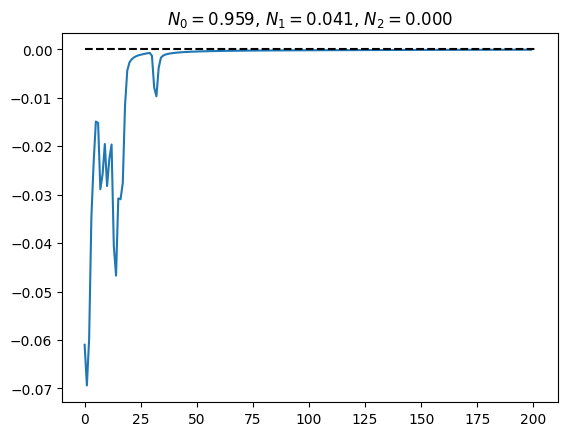

In [3]:
n0, n1, n2 = (dz*(psi*psi.conj()).real.reshape((3, nz, 201)).sum(axis=1))[:, -1]
plt.plot(np.gradient(chemical_pot))
plt.hlines(0, xmin=0, xmax=201, linestyle='--', color='k')
plt.title(f'$N_0=${n0:.3f}, $N_1=${n1:.3f}, $N_2=${n2:.3f}')

In [2]:
psi_gs = ground_state(400000, 0.04)

In [2]:
# psi0 = (np.sqrt(np.abs(mu - U)) + 0j)*(U < mu)                    
# norm = ((dz*psi0*psi0.conj()).real).sum()                               
# psi0 = psi0/np.sqrt(norm)                                               
# psi_initial = np.array([psi0/np.sqrt(3),                                    
#                         psi0/np.sqrt(3),                                    
#                         psi0/np.sqrt(3)]).reshape(3*nz)
# psi_gs = split_step_imag_time(psi_initial, 400000, 0.04)

In [3]:
n = (psi_gs*psi_gs.conj()).real.reshape((3, nz))

In [4]:
dz*n.sum(axis=1)

array([9.56045610e-01, 4.38062323e-02, 1.48158129e-04])

In [5]:
# plt.plot(z, U + UL+g_1d*n.sum(axis=0))

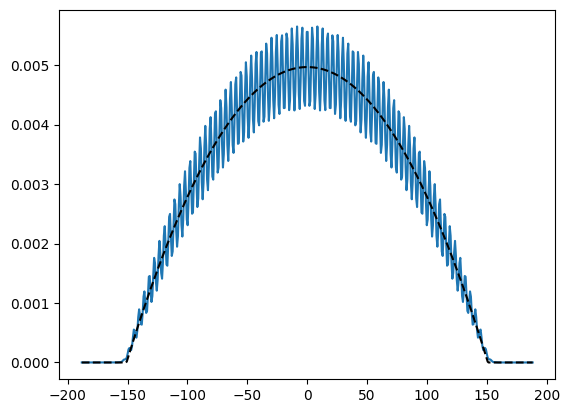

In [6]:
ntf = (mu - U)*(mu>U)/g_1d
ntf = ntf#/(ntf.sum())#*((n[0]).sum())
plt.plot(z, n.sum(axis=0))
plt.plot(z, ntf, '--k')

In [7]:
time_of_flight = 50e-3/t_unit

t_steps = time_of_flight//0.005
dt_size = time_of_flight / t_steps
frames = 201
t_axis = time_of_flight*np.arange(frames)/(frames-1)

psi = rk4(fun=sequence_detuning_quench,
          y0=psi_gs,
          frames=frames,
          steps=t_steps,
          step_size=dt_size,
          delta=delta_i)

In [8]:
nt = (psi*psi.conj()).real.reshape((3, nz, frames))

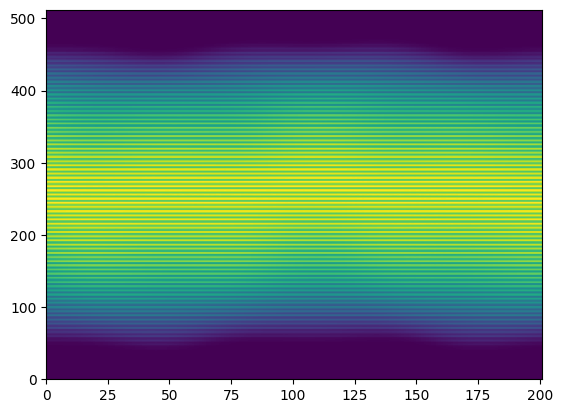

In [9]:
plt.pcolormesh(nt.sum(axis=0))

In [53]:
a = np.sin(4*pi*z/lz)
da = np.fft.ifft((1j*kz*np.fft.fft(a)))

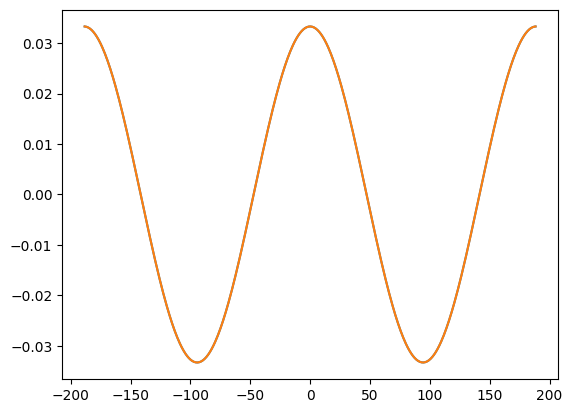

In [54]:
plt.plot(z, 4*pi/lz*np.cos(4*pi*z/lz))
plt.plot(z, da.real)

In [13]:
lz

np.float64(377.3648385177436)

In [13]:
1/(kz.max()**2+U.max()+UL.max())

np.float64(0.04901815532802111)

In [15]:
delta_i

0.0